# Análise dos dados fundiários - SIGEF/SNCI

## Imports

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import find_dotenv, load_dotenv
import os
from rasterstats import zonal_stats
import gcsfs
import gc
from tqdm.auto import tqdm

## Paths

In [2]:
dotenv_path = find_dotenv()
load_dotenv(dotenv_path)

project_root = os.path.dirname(dotenv_path)

KEY_PATH_RELATIVE = os.getenv("GOOGLE_APPLICATION_CREDENTIALS")
if KEY_PATH_RELATIVE:
    KEY_PATH_ABSOLUTE = os.path.join(project_root, KEY_PATH_RELATIVE)
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = KEY_PATH_ABSOLUTE
    print(f"Credenciais carregadas com sucesso de: {KEY_PATH_ABSOLUTE}")
else:
    print(
        "Aviso: A variável GOOGLE_APPLICATION_CREDENTIALS não foi encontrada no arquivo .env"
    )
    print("O acesso ao GCS pode falhar.")

BUCKET_NAME = os.getenv("GCS_BUCKET_NAME")
SIGEF_PATH = (
    f"gs://{BUCKET_NAME}/raw/land_tenure/Sigef Brasil.shp"
)
SNCI_PATH = (
    f"gs://{BUCKET_NAME}/raw/land_tenure/Imóvel certificado SNCI Brasil.shp"
)
STATES_PATH = f"gs://{BUCKET_NAME}/raw/state_lines/BR_UF_2024.shp"
TIFF_MASCARA_PATH = f"gs://{BUCKET_NAME}/processed/mascara_exclusao_total.tif" 

Credenciais carregadas com sucesso de: g:\BackupC\Faculdade\UFRJ\TCC\analise-geografica-energia-solar-brasil\.secrets/tcc-usinas-solares-brasil-29b2750a20f8.json


## Carregamento de dados

In [3]:
states_gdf = gpd.read_file(STATES_PATH)

In [4]:
amostra_sigef = gpd.read_file(SIGEF_PATH, engine="pyogrio", rows=1)
print(f"Colunas SIGEF: {list(amostra_sigef.columns)}\n")
print(f"Linha SIGEF: {amostra_sigef.head()}\n")

Colunas SIGEF: ['parcela_co', 'rt', 'art', 'situacao_i', 'codigo_imo', 'data_submi', 'data_aprov', 'status', 'nome_area', 'registro_m', 'registro_d', 'municipio_', 'uf_id', 'geometry']

Linha SIGEF:                              parcela_co   rt               art  situacao_i  \
0  205378c5-4907-4994-9e9a-6cc5b028cc95  FEB  PB20170146496-PB  REGISTRADA   

      codigo_imo data_submi data_aprov       status          nome_area  \
0  2073220011806 2017-08-25 2017-08-25  CERTIFICADA  SITIO MAIPU - R-1   

  registro_m registro_d  municipio_  uf_id  \
0       3807        NaT     2514909     25   

                                            geometry  
0  POLYGON Z ((-37.17298 -6.86809 234.981, -37.17...  



In [5]:
amostra_snci = gpd.read_file(SNCI_PATH, engine="pyogrio", rows=1)
print(f"Colunas SNCI: {list(amostra_snci.columns)}\n")
print(f"Linha SNCI: {amostra_snci.head()}\n")

Colunas SNCI: ['num_proces', 'sr', 'num_certif', 'data_certi', 'qtd_area_p', 'cod_profis', 'cod_imovel', 'nome_imove', 'uf_municip', 'geometry']

Linha SNCI:              num_proces  sr       num_certif data_certi qtd_area_p cod_profis  \
0  54290.000770/2012-13  16  161803000081-14 2018-03-29   266.7786        FKH   

      cod_imovel                       nome_imove uf_municip  \
0  9080370313217  FAZENDA NOSSA SENHORA APARECIDA         MS   

                                            geometry  
0  POLYGON ((-54.43728 -17.85083, -54.43115 -17.8...  



In [6]:
# Cortando colunas irrelevantes na leitura para evitar sobrecarregar a memória RAM
snci_gdf = gpd.read_file(
    SNCI_PATH,
    engine="pyogrio",
    columns=['cod_imovel', 'nome_imove'],
)

snci_gdf = snci_gdf.rename(columns={'cod_imovel': 'id_imovel', 'nome_imove': 'nome_imovel'})
snci_gdf['fonte'] = 'SNCI'
print(f"SNCI carregado: {len(snci_gdf):,} latifúndios.")

SNCI carregado: 53,690 latifúndios.


In [7]:
# Cortando colunas irrelevantes na leitura para evitar sobrecarregar a memória RAM
sigef_gdf = gpd.read_file(
    SIGEF_PATH,
    engine="pyogrio",
    columns=['codigo_imo', 'nome_area']
)
sigef_gdf = sigef_gdf.rename(columns={'codigo_imo': 'id_imovel', 'nome_area': 'nome_imovel'})
sigef_gdf['fonte'] = 'SIGEF'
print(f"SIGEF carregado: {len(sigef_gdf):,} latifúndios.")

SIGEF carregado: 1,687,276 latifúndios.


## Processamento dos dados

### Junção da base SNCI com SIGEF

In [8]:
fundiario_br = pd.concat([sigef_gdf, snci_gdf], ignore_index=True)
print(f"Total bruto unificado: {len(fundiario_br):,} propriedades.")

Total bruto unificado: 1,740,966 propriedades.


### Cálculo da área das propriedades

In [9]:
# Reprojetando para Equal-Area para garantir que 1 hectare no Amazonas meça o mesmo que 1 hectare no RS
fundiario_br_calc = fundiario_br.to_crs("EPSG:6933")
fundiario_br['area_bruta_ha'] = fundiario_br_calc.geometry.area / 10000.0

### Filtrando apenas terrenos com >= 100 ha

In [10]:
fundiario_br_100ha = fundiario_br[fundiario_br['area_bruta_ha'] >= 100].copy()

### Limpando a memória dos dados não-filtrados

In [11]:
del snci_gdf
del sigef_gdf
del fundiario_br
del fundiario_br_calc
gc.collect()

0

### Voltando à projeção original

In [12]:
fundiario_br_100ha = fundiario_br_100ha.to_crs("EPSG:4674")

In [13]:
print(f"Total de Latifúndios no Brasil com área >100ha: {len(fundiario_br_100ha):,}")

Total de Latifúndios no Brasil com área >100ha: 463,673


## Mapa Geral Fundiário

C:\Users\JPMar\AppData\Local\Temp\ipykernel_37272\3838755893.py:17: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\JPMar\AppData\Local\Temp\ipykernel_37272\3838755893.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


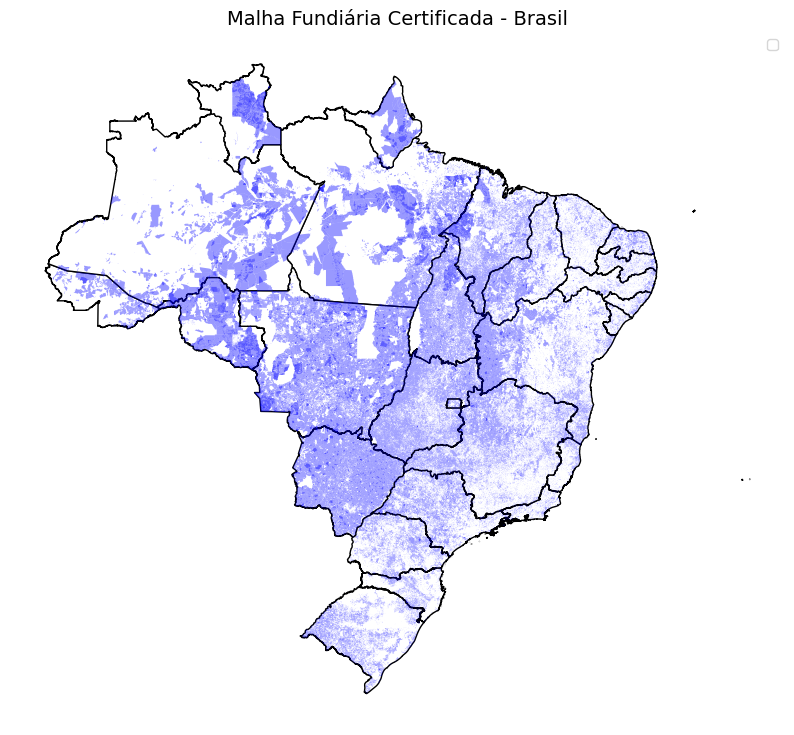

In [14]:
# Garantir que os dados usem o mesmo CRS do mapa base (EPSG:4674)
if fundiario_br_100ha.crs != states_gdf.crs:
    fundiario_br_100ha = fundiario_br_100ha.to_crs(states_gdf.crs)

# Gerar o Mapa
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plotar as divisórias de estados
states_gdf.plot(ax=ax, color="white", edgecolor="black", linewidth=1)

# Plotar os dados
fundiario_br_100ha.plot(ax=ax, color="blue", alpha=0.4, label="SNCI")

ax.set_title("Malha Fundiária Certificada - Brasil", fontsize=14)
ax.set_axis_off()

plt.legend()
plt.show()

## Cruzamento com máscara de restrições

In [15]:
# Processamento em lotes para não explodir a memória RAM, usando tqdm para acompanhar o progresso
TAMANHO_LOTE = 10000
total_lotes = (len(fundiario_br_100ha) // TAMANHO_LOTE) + 1

resultados_stats = []

print(f"Total de lotes a processar: {total_lotes}")

# Extraindo apenas as geometrias para processar mais rápido
geometrias = fundiario_br_100ha['geometry'].values

# O loop do processamento com tqdm para mostrar o progresso
for i in tqdm(range(0, len(geometrias), TAMANHO_LOTE), desc="Processando Lotes"):
    
    lote_geom = geometrias[i : i + TAMANHO_LOTE]
    
    # Calcula apenas a média (percentual de sobreposição com áreas de exclusão)
    stats_lote = zonal_stats(
        lote_geom, 
        TIFF_MASCARA_PATH, 
        stats="mean", 
        nodata=255 # Ajuste se o NoData do seu TIF for diferente (ex: 0, -9999)
    )
    
    resultados_stats.extend(stats_lote)
    
    # Limpeza de memória a cada lote
    del lote_geom
    del stats_lote
    gc.collect()

Total de lotes a processar: 47


Processando Lotes:   0%|          | 0/47 [00:00<?, ?it/s]

In [16]:
print("\n2. Consolidando resultados e calculando a Área Útil...")
# Adiciona a coluna de média ao DataFrame principal
# Se for None (polígono caiu fora do raster), assume 0 exclusão
medias = [d['mean'] if d['mean'] is not None else 0 for d in resultados_stats]
fundiario_br_100ha['percentual_exclusao'] = medias

# Cálculo matemático elegante da área útil
fundiario_br_100ha['area_util_ha'] = fundiario_br_100ha['area_bruta_ha'] * (1 - fundiario_br_100ha['percentual_exclusao'])

print("\n3. Aplicando o último filtro: Retendo apenas latifúndios com ÁREA ÚTIL >= 100ha...")
candidatos_br_finais = fundiario_br_100ha[fundiario_br_100ha['area_util_ha'] >= 100].copy()

# Cálculo do Potencial Técnico (Premissa: 3.6 ha por MW)
candidatos_br_finais['potencial_mw'] = candidatos_br_finais['area_util_ha'] / 3.6

print("-" * 65)
print("ETAPA 2 CONCLUÍDA: A PENEIRA FINAL DO BRASIL")
print("-" * 65)
print(f"Fazendas Iniciais (>100ha brutas): {len(fundiario_br_100ha):,}")
print(f"Candidatos Finais (>100ha úteis) : {len(candidatos_br_finais):,}")
print(f"Potencial Técnico Nacional Mapeado: {candidatos_br_finais['potencial_mw'].sum() / 1000:,.2f} GW")
print("-" * 65)


2. Consolidando resultados e calculando a Área Útil...

3. Aplicando o último filtro: Retendo apenas latifúndios com ÁREA ÚTIL >= 100ha...
-----------------------------------------------------------------
ETAPA 2 CONCLUÍDA: A PENEIRA FINAL DO BRASIL
-----------------------------------------------------------------
Fazendas Iniciais (>100ha brutas): 463,673
Candidatos Finais (>100ha úteis) : 419,133
Potencial Técnico Nacional Mapeado: 80,215.13 GW
-----------------------------------------------------------------


In [17]:
# Salvando o Ouro Nacional (Use .parquet ou .gpkg)
candidatos_br_finais.to_file("../data/processed/candidatos_solares_brasil_limpo.gpkg", driver="GPKG", engine="pyogrio")
print("Dados nacionais salvos com segurança!")

Dados nacionais salvos com segurança!


## Exportando os dados tratados

In [18]:
fs = gcsfs.GCSFileSystem(token=KEY_PATH_ABSOLUTE)
BUCKET_NAME = os.getenv('GCS_BUCKET_NAME')
RESULT_OUTPUT_PATH = f"gs://{BUCKET_NAME}/processed/candidatos_solares_brasil_limpo.gpkg"
TEMP_LOCAL_FILE = "temp_candidatos_brasil.gpkg"

if fs.exists(RESULT_OUTPUT_PATH):
    print(f"O arquivo já existe na nuvem: {RESULT_OUTPUT_PATH}")
    print("Fazendo download temporário para leitura eficiente...")
    
    fs.get(RESULT_OUTPUT_PATH, TEMP_LOCAL_FILE)
    
    print("Carregando o arquivo processado na memória...")
    candidatos_gdf_final = gpd.read_file(TEMP_LOCAL_FILE, engine="fiona")
    
    os.remove(TEMP_LOCAL_FILE)
    print("Leitura concluída e arquivo temporário removido!")

else:
    print("Arquivo não encontrado na nuvem. Iniciando o processamento completo...")
    candidatos_gdf_final = candidatos_br_finais.to_crs(epsg=4674)
    
    print("1. Gerando o banco de dados espacial localmente...")
    candidatos_gdf_final.to_file(TEMP_LOCAL_FILE, driver="GPKG", engine="fiona")
    
    print(f"2. Fazendo upload binário para o GCS: {RESULT_OUTPUT_PATH}...")
    fs.put(TEMP_LOCAL_FILE, RESULT_OUTPUT_PATH)
    
    print("3. Limpando o arquivo temporário local...")
    os.remove(TEMP_LOCAL_FILE)
    
    print("Processamento e salvamento concluídos!")

print(f"\nCandidatos solares prontos na memória (Total: {len(candidatos_gdf_final):,} | CRS: {candidatos_gdf_final.crs}).")

O arquivo já existe na nuvem: gs://tcc-usinas-solares-brasil-dados/processed/candidatos_solares_brasil_limpo.gpkg
Fazendo download temporário para leitura eficiente...
Carregando o arquivo processado na memória...
Leitura concluída e arquivo temporário removido!

Candidatos solares prontos na memória (Total: 419,133 | CRS: EPSG:4674).
